<a href="https://colab.research.google.com/github/Kirkumee/study/blob/main/%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D1%8C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spectral

import gc
gc.collect()
import warnings
warnings.filterwarnings('ignore')
import time
import numpy as np
from operator import truediv
import scipy.io as sio
import os
import pandas as pd
import seaborn as sns
import spectral
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dropout, Input, Conv3D, Flatten, Dense
from keras.models import Model
from keras.optimizers import Adam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 3.8 MB/s eta 0:00:00


In [6]:
from google.colab import files
print("Загрузите PaviaU.mat")
files.upload()
print("Загрузите PaviaU_gt.mat")
files.upload()

Загрузите PaviaU.mat


Saving PaviaU.mat to PaviaU (1).mat
Загрузите PaviaU_gt.mat


Saving PaviaU_gt.mat to PaviaU_gt.mat


{'PaviaU_gt.mat': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May 20 18:25:52 2011                                                \x00\x01IM\x0f\x00\x00\x00u*\x00\x00x\x9c\xe4\x98\xcfN\x840\x10\xc6\xa7\x0b\x1a\xb8\xf8\x1c\xc6\xe7\xd1\xb3\xd9\xbd\xa87\x0f\xc6\xe7\x17W\x14:\xff\x07h!q\x92\xcd.t\x98~\xed\xf7K\xdb\xe5\x0e\x00^\x1f\x1a\xb8\x1d\xbe\xbb\xe1\xd3\xc3O\xdc\x8c\xd7\x97\x13\xc0c\x02Hc\xdb\xfb\xf9\xf3\xed\xfc\xf4\xfc\xf21\xe6\r\xcdp?<\xbfM\xa4\x94\xf2\x1b\'.\xec:(/e\xb1\x91\xd6\x95\xd1\xfc\xc6Ad\xf0Z\xe8\x84;\x1d\x80\xd9\xac\x0b\xed\xac\xb7r\x84\x87&\x89\xf2\xa8\xb0\xca\xe0\xb4t@\xc4\x14[K\xf5\xa8\xcb\xe0\xd5\xe0)\x8f\xb8\xcdLx\xcb\x94\xaeI\x98\x130\xab3\x92\x96pl\xa2ve\xd4FL\xe8\x88 \xc63\xc6_\x19\x81\xe7\xbbmw&\x8cx\xbf\xb07\x0308\x08e\xea\xf6T\xac;U\x86\xb6\x8c\x91\xdf\x8e@\x88e\x80E\x11\x8b\x8dV\xd4\xc3*\xa0\x92\xd42$\xe7Z6\x1f\xeb?dL\xee\xc9\xcfX\xdchu\xdb\xa8M\x98\xb4G2\x82\xd4:8\x87\xc7\xea\x10\x8cM~\xd6cLn\xb1Oc\x0b|&\x88\xcd\xb7\xca\x9d\t#\x95C\x80\xfd%a\xaa\

In [7]:
def SplitTr_Te(HSI, GT, TeRatio, randomState=345):
    Tr, Te, TrC, TeC = train_test_split(
        HSI, GT, test_size=TeRatio, random_state=randomState, stratify=GT)
    return Tr, Te, TrC, TeC

def DL_Method(HSI, numComponents=20):
    RHSI = np.reshape(HSI, (-1, HSI.shape[2]))
    n_batches = 256
    inc_pca = IncrementalPCA(n_components=numComponents)
    for X_batch in np.array_split(RHSI, n_batches):
        inc_pca.partial_fit(X_batch)
    X_ipca = inc_pca.transform(RHSI)
    RHSI = np.reshape(X_ipca, (HSI.shape[0], HSI.shape[1], numComponents))
    return RHSI

def ZeroPad(HSI, margin=2):
    NHSI = np.zeros((HSI.shape[0] + 2*margin,
                     HSI.shape[1] + 2*margin,
                     HSI.shape[2]))
    NHSI[margin:HSI.shape[0]+margin, margin:HSI.shape[1]+margin, :] = HSI
    return NHSI

def HSICubes(HSI, GT, WinSize=11, removeZeroLabels=True):
    margin = int((WinSize - 1) / 2)
    zeroPaddedX = ZeroPad(HSI, margin=margin)
    patchesData   = np.zeros((HSI.shape[0] * HSI.shape[1], WinSize, WinSize, HSI.shape[2]))
    patchesLabels = np.zeros((HSI.shape[0] * HSI.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):
        for c in range(margin, zeroPaddedX.shape[1] - margin):
            patch = zeroPaddedX[r-margin:r+margin+1, c-margin:c+margin+1]
            patchesData[patchIndex, :, :, :] = patch
            patchesLabels[patchIndex] = GT[r-margin, c-margin]
            patchIndex += 1
    if removeZeroLabels:
        patchesData   = patchesData[patchesLabels > 0, :, :, :]
        patchesLabels = patchesLabels[patchesLabels > 0]
        patchesLabels -= 1
    return patchesData, patchesLabels

def AA_andEachClassAccuracy(confusion_matrix):
    list_diag    = np.diag(confusion_matrix)
    list_raw_sum = np.sum(confusion_matrix, axis=1)
    each_acc     = np.nan_to_num(truediv(list_diag, list_raw_sum))
    average_acc  = np.mean(each_acc)
    return each_acc, average_acc

def reports(Te, TeC):
    start  = time.time()
    Y_pred = model.predict(Te)
    y_pred = np.argmax(Y_pred, axis=1)
    end    = time.time()
    total  = end - start

    target_names = ['Asphalt', 'Meadows', 'Gravel', 'Trees',
                    'Painted metal sheets', 'Bare Soil', 'Bitumen',
                    'Self-Blocking Bricks', 'Shadows']

    classification = classification_report(np.argmax(TeC, axis=1), y_pred, target_names=target_names)
    oa        = accuracy_score(np.argmax(TeC, axis=1), y_pred)
    confusion = confusion_matrix(np.argmax(TeC, axis=1), y_pred)
    each_acc, aa = AA_andEachClassAccuracy(confusion)
    kappa     = cohen_kappa_score(np.argmax(TeC, axis=1), y_pred)
    score     = model.evaluate(Te, TeC, batch_size=32, verbose=0)
    Test_Loss     = score[0] * 100
    Test_accuracy = score[1] * 100
    return classification, confusion, Test_Loss, Test_accuracy, oa*100, each_acc*100, aa*100, kappa*100, target_names, y_pred, total

def Patch(data, height_index, width_index):
    height_slice = slice(height_index, height_index + PATCH_SIZE)
    width_slice  = slice(width_index,  width_index  + PATCH_SIZE)
    return data[height_slice, width_slice, :]

In [8]:
HSI = sio.loadmat('PaviaU.mat')['paviaU']
GT  = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']
print("HSI:", HSI.shape)  # (610, 340, 103)
print("GT: ", GT.shape)   # (610, 340)

# iPCA -> 20 компонент
HSI = DL_Method(HSI, numComponents=20)
print("После PCA:", HSI.shape)

# Патчи 11x11x20
HSI, GT = HSICubes(HSI, GT, WinSize=11)
print("Патчи:", HSI.shape)

# Train/Test 70/30
Tr, Te, TrC, TeC = SplitTr_Te(HSI, GT, 0.30)

# Train/Val 70/30
Tr, Tv, TrC, TvC = SplitTr_Te(Tr, TrC, 0.30)
print("Train:", Tr.shape, "Val:", Tv.shape, "Test:", Te.shape)

# Reshape для модели
Tr  = Tr.reshape(-1, 11, 11, 20, 1).astype('float32')
Tv  = Tv.reshape(-1, 11, 11, 20, 1).astype('float32')
Te  = Te.reshape(-1, 11, 11, 20, 1).astype('float32')

num_classes = 9
TrC = tf.keras.utils.to_categorical(TrC, num_classes)
TvC = tf.keras.utils.to_categorical(TvC, num_classes)
TeC = tf.keras.utils.to_categorical(TeC, num_classes)

HSI: (610, 340, 103)
GT:  (610, 340)
После PCA: (610, 340, 20)
Патчи: (42776, 11, 11, 20)
Train: (20960, 11, 11, 20) Val: (8983, 11, 11, 20) Test: (12833, 11, 11, 20)


In [9]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [10]:
HSI_raw = sio.loadmat('PaviaU.mat')['paviaU']
GT_raw  = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']

height, width = GT_raw.shape
n_classes = 9

# iPCA 103 -> 20
flat = HSI_raw.reshape(-1, HSI_raw.shape[2])
pca = IncrementalPCA(n_components=20)
for batch in np.array_split(flat, 256):
    pca.partial_fit(batch)
X_pca = pca.transform(flat)  # (610*340, 20)

# Только размеченные пиксели
mask     = GT_raw.flatten() > 0
X_masked = X_pca[mask]
y_true   = GT_raw.flatten()[mask] - 1  # метки 0..8

print("Размеченных пикселей:", X_masked.shape[0])

Размеченных пикселей: 42776


In [11]:
def match_clusters(y_pred, y_true, n):
    """Венгерский алгоритм — сопоставляет кластеры с реальными классами"""
    cost = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            cost[i, j] = -np.sum((y_pred == i) & (y_true == j))
    row, col = linear_sum_assignment(cost)
    mapping = dict(zip(row, col))
    return np.array([mapping[l] for l in y_pred])

CLASS_NAMES = ['Asphalt', 'Meadows', 'Gravel', 'Trees',
               'Painted metal sheets', 'Bare Soil', 'Bitumen',
               'Self-Blocking Bricks', 'Shadows']

In [12]:
# K-Means
print("K-Means...")
km = KMeans(n_clusters=n_classes, n_init=10, random_state=42)
km_pred = match_clusters(km.fit_predict(X_masked), y_true, n_classes)
print("  готов")

# GMM
print("GMM...")
gmm = GaussianMixture(n_components=n_classes, n_init=3, random_state=42)
gmm_pred = match_clusters(gmm.fit_predict(X_masked), y_true, n_classes)
print("  готов")

# Agglomerative (на подвыборке 20000 — иначе очень долго)
print("Agglomerative (подвыборка 20000)...")
np.random.seed(42)
idx    = np.random.choice(len(X_masked), size=20000, replace=False)
agg    = AgglomerativeClustering(n_clusters=n_classes, linkage='ward')
agg_sub = match_clusters(agg.fit_predict(X_masked[idx]), y_true[idx], n_classes)
print("  готов")

K-Means...
  готов
GMM...
  готов
Agglomerative (подвыборка 20000)...
  готов


In [13]:
print("=" * 62)
print(f"{'Алгоритм':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 62)

algo_results = {
    'K-Means':       (km_pred,  y_true),
    'GMM':           (gmm_pred, y_true),
    'Agglomerative': (agg_sub,  y_true[idx]),
}

for name, (pred, ref) in algo_results.items():
    p  = precision_score(ref, pred, average='weighted', zero_division=0)
    r  = recall_score(ref, pred, average='weighted', zero_division=0)
    f1 = f1_score(ref, pred, average='weighted', zero_division=0)
    print(f"{name:<22} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")

print("=" * 62)

# Детально по классам для K-Means
print("\nДетально по классам (K-Means):")
print(f"{'Класс':<26} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 58)
for i, cls in enumerate(CLASS_NAMES):
    p  = precision_score(y_true, km_pred, average=None, zero_division=0)[i]
    r  = recall_score(y_true, km_pred, average=None, zero_division=0)[i]
    f1 = f1_score(y_true, km_pred, average=None, zero_division=0)[i]
    print(f"{cls:<26} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")

Алгоритм                Precision     Recall         F1
K-Means                    0.6221     0.5177     0.5270
GMM                        0.6710     0.4528     0.4660
Agglomerative              0.6109     0.5762     0.5749

Детально по классам (K-Means):
Класс                       Precision     Recall         F1
----------------------------------------------------------
Asphalt                        0.7695     0.8845     0.8230
Meadows                        0.7914     0.3770     0.5107
Gravel                         0.0000     0.0000     0.0000
Trees                          0.4944     0.5894     0.5377
Painted metal sheets           0.8800     0.6052     0.7172
Bare Soil                      0.2690     0.4263     0.3299
Bitumen                        0.0000     0.0000     0.0000
Self-Blocking Bricks           0.4762     0.9620     0.6371
Shadows                        0.9968     0.9989     0.9979


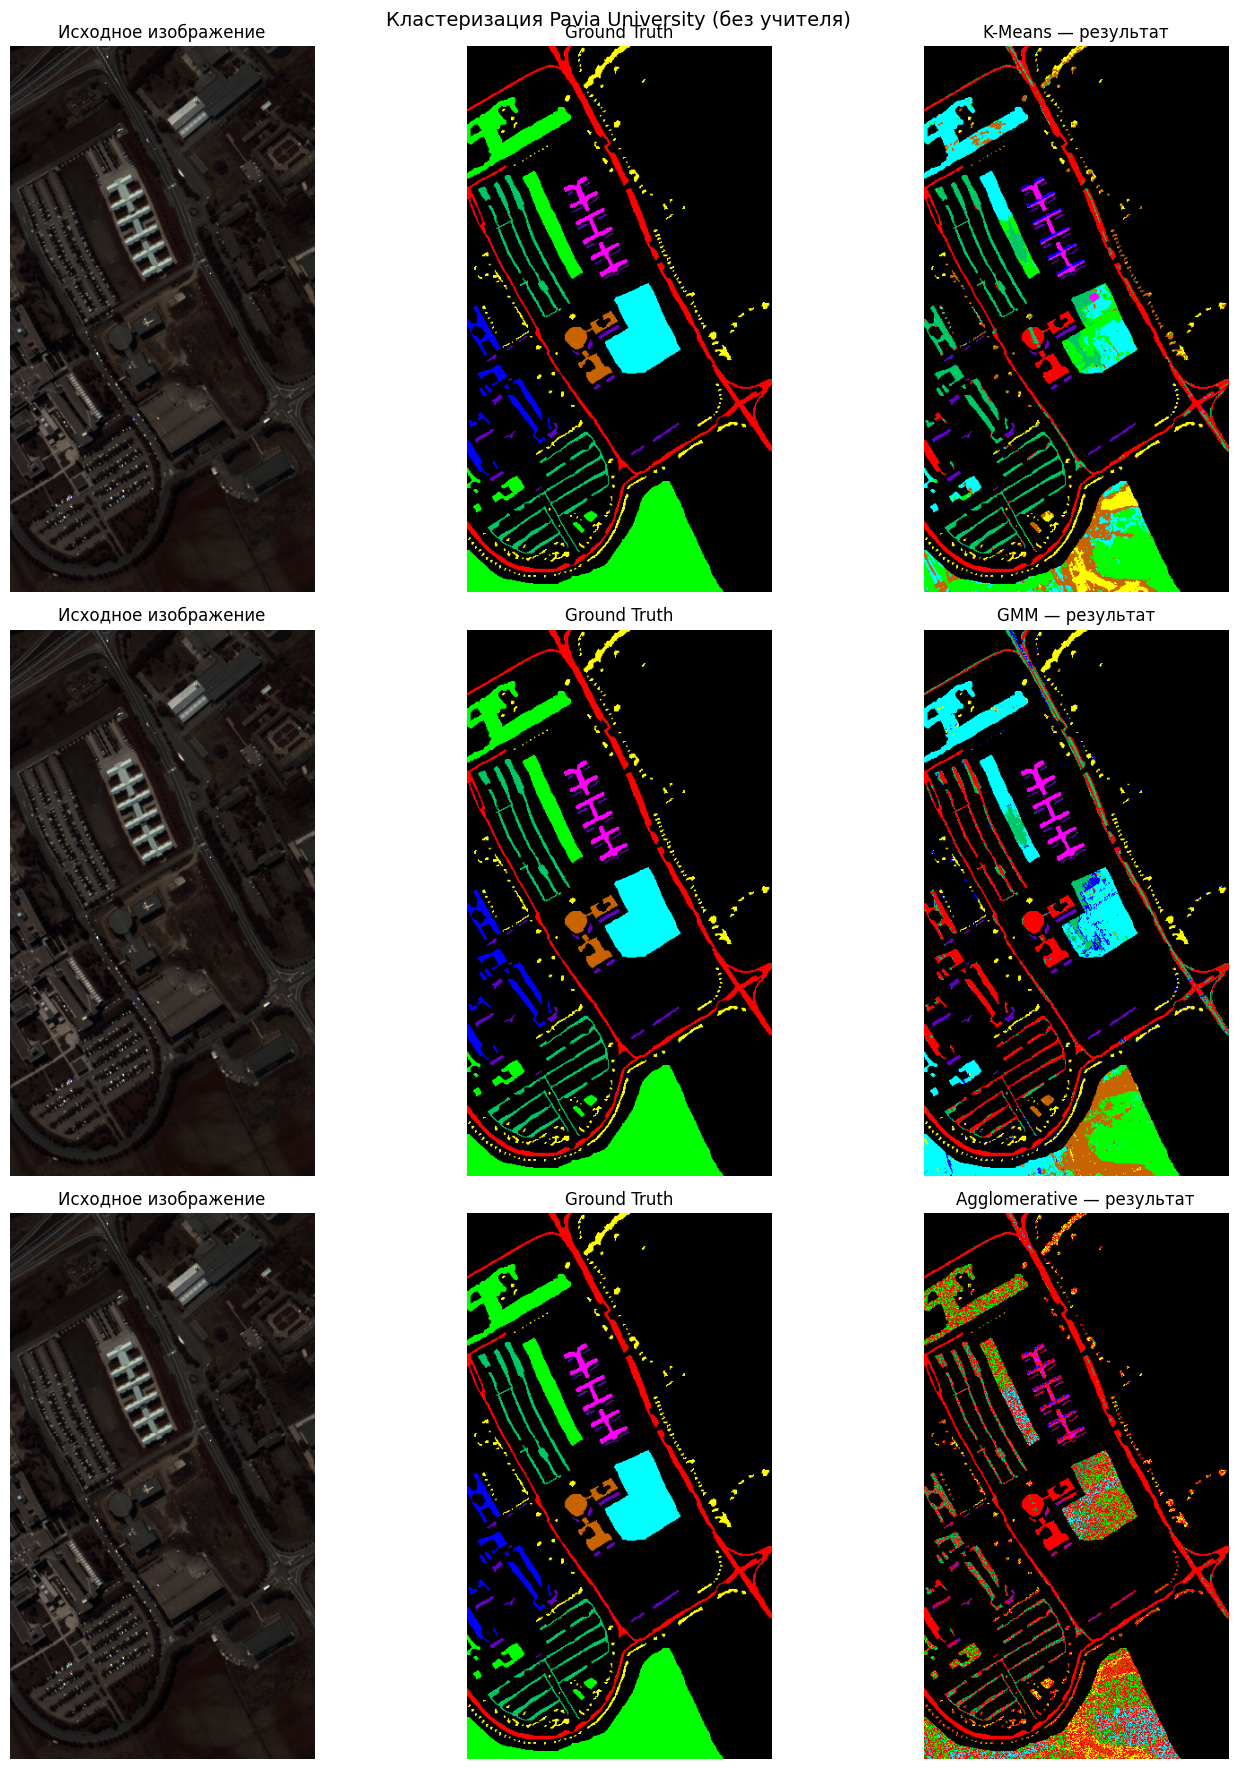

Сохранено: clustering_results.png


In [14]:
import spectral
spy = np.array(spectral.spy_colors) / 255.0

def make_map(pred_labels, mask_flat, h, w):
    img = np.zeros((h * w, 3))
    img[mask_flat] = spy[pred_labels + 1]
    return img.reshape(h, w, 3)

# Исходное RGB (каналы 30, 20, 10)
rgb = HSI_raw[:, :, [30, 20, 10]].astype(float)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

# Ground Truth карта
gt_map = np.zeros((height * width, 3))
gt_flat = GT_raw.flatten()
for c in range(1, 10):
    gt_map[gt_flat == c] = spy[c]
gt_map = gt_map.reshape(height, width, 3)

# Карты алгоритмов
km_map  = make_map(km_pred,  mask, height, width)
gmm_map = make_map(gmm_pred, mask, height, width)

agg_full = np.zeros(mask.sum(), dtype=int)
agg_full[idx] = agg_sub
agg_map = make_map(agg_full, mask, height, width)

# Таблица 3x3: строки = алгоритмы, столбцы = исх/GT/результат
fig, axes = plt.subplots(3, 3, figsize=(15, 18))
algo_names = ['K-Means', 'GMM', 'Agglomerative']
pred_maps  = [km_map, gmm_map, agg_map]

for row in range(3):
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title('Исходное изображение')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt_map)
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_maps[row])
    axes[row, 2].set_title(f'{algo_names[row]} — результат')
    axes[row, 2].axis('off')

    axes[row, 0].set_ylabel(algo_names[row], fontsize=13,
                             rotation=0, labelpad=90, va='center')

plt.suptitle('Кластеризация Pavia University (без учителя)', fontsize=14)
plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: clustering_results.png")